# Figure 2: Missingness Effects Comparison

This notebook creates a 2-panel figure comparing phase diagrams for single-view vs joint missingness patterns in PLS-SVD.

**Panels:**
- (a) Phase diagram for X-only missingness (m_Y = 0): rho = 1-m (linear degradation)
- (b) Phase diagram for joint missingness (m_X = m_Y = m): rho = (1-m)^2 (quadratic degradation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from multiprocessing import Pool
from src import _run_grid_worker
from tqdm.notebook import tqdm
import pickle
import os

# ICML single-column styling
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

np.random.seed(42)

# Create directories
os.makedirs('../results', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

## Parameters

In [2]:
# Grid parameters for phase diagrams
N_pd = 800
Dx_pd = 200
Dy_pd = 200
theta_grid = np.linspace(0.3, 2.0, 50)
m_grid = np.linspace(0.0, 0.9, 50)
n_trials_pd = 30

# Compute aspect ratios
alpha_x = N_pd / Dx_pd
alpha_y = N_pd / Dy_pd

print(f"Parameters: N={N_pd}, Dx={Dx_pd}, Dy={Dy_pd}")
print(f"Aspect ratios: alpha_x={alpha_x:.1f}, alpha_y={alpha_y:.1f}")
print(f"Grid: {len(theta_grid)} x {len(m_grid)} = {len(theta_grid)*len(m_grid)} points")

Parameters: N=800, Dx=200, Dy=200
Aspect ratios: alpha_x=4.0, alpha_y=4.0
Grid: 50 x 50 = 2500 points


## Phase Diagram 1: X-only Missingness

In [3]:
results_file = '../results/fig2_results.pkl'

if os.path.exists(results_file):
    print("Loading results...")
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    data_d = all_results['x_only']
    Rx2_empirical_d = data_d['Rx2_empirical']
    Rx2_theoretical_d = data_d['Rx2_theoretical']
    print(f"  Loaded X-only {Rx2_empirical_d.shape} grid.")
else:
    print("Running Phase diagram (X-only) experiment...")
    
    args_list = []
    for i, m in enumerate(m_grid):
        for j, th in enumerate(theta_grid):
            params_dict = {'N': N_pd, 'Dx': Dx_pd, 'Dy': Dy_pd, 'theta': th, 'mx': m, 'my': 0.0}
            args_list.append((params_dict, n_trials_pd, i, j))
    
    with Pool() as pool:
        results_raw = list(tqdm(pool.imap(_run_grid_worker, args_list),
                                total=len(args_list), desc="  Phase (X-only)"))
    
    Rx2_empirical_d = np.zeros((len(m_grid), len(theta_grid)))
    Rx2_theoretical_d = np.zeros((len(m_grid), len(theta_grid)))
    
    for i, j, rx2_emp, rx2_theory in results_raw:
        Rx2_empirical_d[i, j] = rx2_emp
        Rx2_theoretical_d[i, j] = rx2_theory
    
    all_results = {}
    all_results['x_only'] = {
        'Rx2_empirical': Rx2_empirical_d,
        'Rx2_theoretical': Rx2_theoretical_d,
        'theta_grid': theta_grid,
        'm_grid': m_grid,
    }
    with open(results_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("  Done! Results saved.")

Loading results...
  Loaded X-only (50, 50) grid.


## Phase Diagram 2: Joint Missingness

In [4]:
if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    if 'joint' in all_results:
        data_e = all_results['joint']
        Rx2_empirical_e = data_e['Rx2_empirical']
        Rx2_theoretical_e = data_e['Rx2_theoretical']
        print(f"  Loaded Joint {Rx2_empirical_e.shape} grid.")
    else:
        raise KeyError("joint not found in results file")
else:
    print("Running Phase diagram (Joint) experiment...")
    
    args_list = []
    for i, m in enumerate(m_grid):
        for j, th in enumerate(theta_grid):
            params_dict = {'N': N_pd, 'Dx': Dx_pd, 'Dy': Dy_pd, 'theta': th, 'mx': m, 'my': m}
            args_list.append((params_dict, n_trials_pd, i, j))
    
    with Pool() as pool:
        results_raw = list(tqdm(pool.imap(_run_grid_worker, args_list),
                                total=len(args_list), desc="  Phase (Joint)"))
    
    Rx2_empirical_e = np.zeros((len(m_grid), len(theta_grid)))
    Rx2_theoretical_e = np.zeros((len(m_grid), len(theta_grid)))
    
    for i, j, rx2_emp, rx2_theory in results_raw:
        Rx2_empirical_e[i, j] = rx2_emp
        Rx2_theoretical_e[i, j] = rx2_theory
    
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    all_results['joint'] = {
        'Rx2_empirical': Rx2_empirical_e,
        'Rx2_theoretical': Rx2_theoretical_e,
        'theta_grid': theta_grid,
        'm_grid': m_grid,
    }
    with open(results_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("  Done! Results saved.")

  Loaded Joint (50, 50) grid.


## Critical Threshold Functions

In [5]:
def theta_crit_single(m, alpha_x, alpha_y):
    """Critical theta for single-view missingness.
    
    For X-only (my=0): rho = 1-m
    theta_crit = 1 / [(alpha_x * alpha_y)^0.25 * sqrt(1-m)]
    """
    rho = 1 - m
    return 1 / ((alpha_x * alpha_y)**0.25 * np.sqrt(rho))

def theta_crit_joint(m, alpha_x, alpha_y):
    """Critical theta for joint missingness.
    
    For joint (mx=my=m): rho = (1-m)^2
    theta_crit = 1 / [(alpha_x * alpha_y)^0.25 * (1-m)]
    """
    rho = (1 - m)**2
    return 1 / ((alpha_x * alpha_y)**0.25 * np.sqrt(rho))

## Create Phase Diagram Figure

/var/folders/1h/rpjt93m90nxf1xwtn92lvfkw0000gn/T/ipykernel_69885/1218753458.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 / ((alpha_x * alpha_y)**0.25 * np.sqrt(rho))
/var/folders/1h/rpjt93m90nxf1xwtn92lvfkw0000gn/T/ipykernel_69885/1218753458.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 / ((alpha_x * alpha_y)**0.25 * np.sqrt(rho))


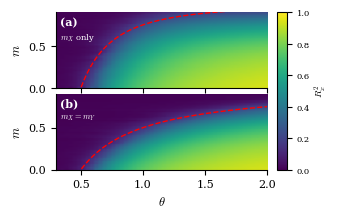


Figure saved: ../figures/fig2_missingness_effects.pdf
Dimensions: 3.25 x 2.1 inches (ICML single-column)


In [6]:
# Create single-column figure (3.25" wide for ICML)
# Layout: 2 rows, 1 column (2 phase diagrams stacked, shared x-axis)

fig = plt.figure(figsize=(3.25, 2.1))
gs = gridspec.GridSpec(2, 1,
                       left=0.08, right=0.73, bottom=0.18, top=0.93,
                       hspace=0.08)

# Two phase diagrams stacked vertically
ax_d = fig.add_subplot(gs[0, 0])
ax_e = fig.add_subplot(gs[1, 0], sharex=ax_d)

# ============================================================================
# TOP PANEL: X-only missingness phase diagram
# ============================================================================
im_d = ax_d.imshow(Rx2_empirical_d,
                   extent=[theta_grid[0], theta_grid[-1], m_grid[0], m_grid[-1]],
                   origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)

# Phase boundary for X-only
m_fine = np.linspace(0.01, 1.0, 100)
theta_boundary_single = [theta_crit_single(m, alpha_x, alpha_y) for m in m_fine]
ax_d.plot(theta_boundary_single, m_fine, 'r--', linewidth=1.0)

ax_d.set_xlim([theta_grid[0], theta_grid[-1]])
ax_d.set_ylim([m_grid[0], m_grid[-1]])
ax_d.set_ylabel(r'$m$')
ax_d.text(0.02, 0.95, '(a)', transform=ax_d.transAxes,
          fontsize=8, fontweight='bold', va='top', color='white')
ax_d.text(0.02, 0.75, r'$m_X$ only', transform=ax_d.transAxes,
          fontsize=6, ha='left', va='top', color='white')

# Remove x-ticklabels for top axis to avoid clutter
plt.setp(ax_d.get_xticklabels(), visible=False)

# ============================================================================
# BOTTOM PANEL: Joint missingness phase diagram
# ============================================================================
im_e = ax_e.imshow(Rx2_empirical_e,
                   extent=[theta_grid[0], theta_grid[-1], m_grid[0], m_grid[-1]],
                   origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)

# Phase boundary for joint
theta_boundary_joint = [theta_crit_joint(m, alpha_x, alpha_y) for m in m_fine]
ax_e.plot(theta_boundary_joint, m_fine, 'r--', linewidth=1.0)

ax_e.set_xlim([theta_grid[0], theta_grid[-1]])
ax_e.set_ylim([m_grid[0], m_grid[-1]])
ax_e.set_xlabel(r'$\theta$')
ax_e.set_ylabel(r'$m$')
ax_e.text(0.02, 0.95, '(b)', transform=ax_e.transAxes,
          fontsize=8, fontweight='bold', va='top', color='white')
ax_e.text(0.02, 0.75, r'$m_X{=}m_Y$', transform=ax_e.transAxes,
          fontsize=6, ha='left', va='top', color='white')

# Shared colorbar for phase diagrams (on the right)
cbar_ax = fig.add_axes([0.76, 0.18, 0.03, 0.75])
cbar = fig.colorbar(im_e, cax=cbar_ax)
cbar.set_label(r'$R_x^2$', fontsize=7, labelpad=2)
cbar.ax.tick_params(labelsize=6)

# ============================================================================
# Save figure
# ============================================================================
plt.savefig('../figures/fig2_missingness_effects.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Figure saved: ../figures/fig2_missingness_effects.pdf")
print("Dimensions: 3.25 x 2.1 inches (ICML single-column)")
print("="*70)